In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_json('cleaned_meta_beauty.json', lines=True)


In [2]:
from sklearn.metrics import silhouette_score

def find_k(scaled_features):
    sse = [] 
    k_range = range(2, 10)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
        kmeans.fit(scaled_features)
        sse.append(kmeans.inertia_)

    plt.figure(figsize=(8, 5))
    plt.plot(k_range, sse, marker='o')
    plt.title('The Elbow Method')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('SSE (Inertia)')
    plt.show()
    return 0

def silhouette_score_fn(scaled_features):
    scores = []
    k_range = range(2, 11)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
        labels = kmeans.fit_predict(scaled_features)
        score = silhouette_score(scaled_features, labels)
        scores.append(score)
        print(f"For k={k}, Silhouette Score is {score:.4f}")

    # Plotting the scores
    plt.plot(k_range, scores, marker='o', color='red')
    plt.title('Silhouette Scores')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Score (Higher is better)')
    plt.show()
    return 0

In [3]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_extraction import text

df["text_combined"] = (
    df["title"].fillna("") + " " + 
    df["description"].fillna("") + " " + 
    df["features_string"].fillna("")
)

custom_stopwords = ["oz", "pack","0", "1", "2", "3", "4", "5", "bottle", "container","inch","x","set","ounce"]
all_stopwords = list(text.ENGLISH_STOP_WORDS.union(custom_stopwords))

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=all_stopwords, max_features=1000)),
    ('pca', PCA(n_components=100))
])

# Generate PCA features
pca_matrix = pipeline.fit_transform(df["text_combined"])

# Take 10% for initialization (warm-up)
warmup_size = int(len(pca_matrix) * 0.1)
warmup_features = pca_matrix[:warmup_size]
# The rest will be processed point-by-point later
rest_features = pca_matrix[warmup_size:] 

k = 3
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
labels = kmeans.fit_predict(warmup_features)
initial_centroids = kmeans.cluster_centers_

bfr_ds_stats = {}

for cluster_id in range(k):
    # Filter points belonging to this cluster
    cluster_points = warmup_features[labels == cluster_id]
    
    # Calculate N, SUM, and SUMSQ
    n = len(cluster_points)
    sum_vals = np.sum(cluster_points, axis=0)
    sumsq_vals = np.sum(cluster_points**2, axis=0)
    
    # Calculate variance and std_dev immediately
    variance = (sumsq_vals / n) - (sum_vals / n)**2
    std_dev = np.sqrt(variance + 1e-9)
    
    # Store all summary stats
    bfr_ds_stats[cluster_id] = {
        'N': n,
        'SUM': sum_vals,
        'SUMSQ': sumsq_vals,
        'Centroid': initial_centroids[cluster_id],
        'std_dev': std_dev
    }

print(f"BFR Initialization Complete.")
print(f"Features dimension: {warmup_features.shape[1]}")
for cid in bfr_ds_stats:
    print(f"Cluster {cid}: {bfr_ds_stats[cid]['N']} points summarized.")

BFR Initialization Complete.
Features dimension: 100
Cluster 0: 3386 points summarized.
Cluster 1: 5223 points summarized.
Cluster 2: 2650 points summarized.


In [4]:

# perform to the 90% remaining data set


# calculate mahalanobis distance
def get_mahalanobis_dist(point, centroid, std_dev):
    normalized_dist = (point - centroid) / std_dev
    return np.sqrt(np.sum(normalized_dist**2))

threshold = 2*np.sqrt(2) 
retanied_set = []


for point in rest_features:
    
    distances = []
    for cid, stats in bfr_ds_stats.items():
        dist = get_mahalanobis_dist(point, stats['Centroid'], stats['std_dev'])
        distances.append((dist, cid))

    min_dist, best_cid = min(distances)
    
    if min_dist < threshold:
        bfr_ds_stats[best_cid]['N'] += 1
        bfr_ds_stats[best_cid]['SUM'] += point
        bfr_ds_stats[best_cid]['SUMSQ'] += (point**2)
        pass
    else:
        retanied_set.append(point)
   
print(f"the number of outlier : {len(retanied_set)}")      
print(f"the number of data point in cluster 0: {bfr_ds_stats[0]['N']}")
print(f"the number of data point in cluster 1: {bfr_ds_stats[1]['N']}")
print(f"the number of data point in cluster 2: {bfr_ds_stats[2]['N']}")


the number of outlier : 100061
the number of data point in cluster 0: 3387
the number of data point in cluster 1: 6491
the number of data point in cluster 2: 2651


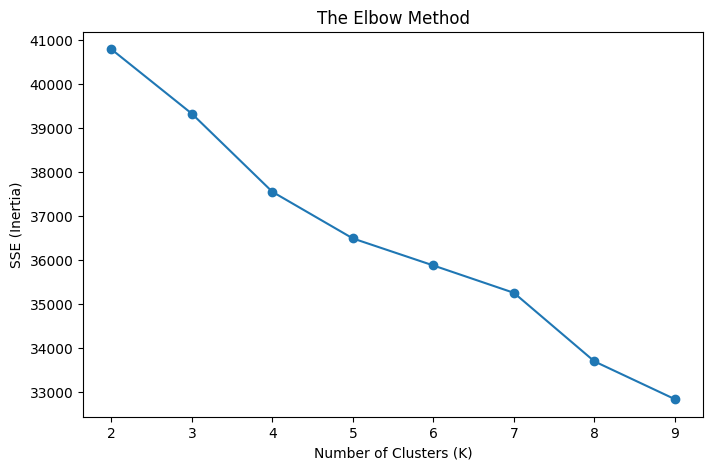

For k=2, Silhouette Score is 0.0991
For k=3, Silhouette Score is 0.0802
For k=4, Silhouette Score is 0.0940
For k=5, Silhouette Score is 0.1030
For k=6, Silhouette Score is 0.0694
For k=7, Silhouette Score is 0.0734
For k=8, Silhouette Score is 0.0920
For k=9, Silhouette Score is 0.1007
For k=10, Silhouette Score is 0.0982


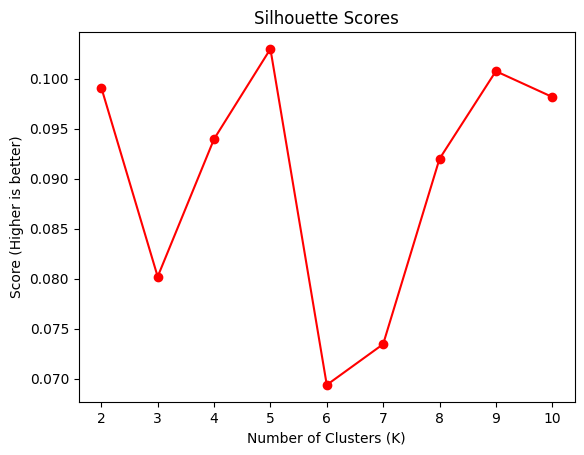

0

In [5]:
# perform clustering on RS to see whether the data belong to CS or RS
from sklearn.cluster import KMeans

# convert list of points to a DataFrame/Array
rs_data = np.array(retanied_set)

# find suitable k value
find_k(rs_data)
silhouette_score_fn(rs_data)

In [6]:
# we select k = 5 because it has the highest silhouette score
kmeans_rs = KMeans(n_clusters=5, init='k-means++', random_state=42)
rs_labels = kmeans_rs.fit_predict(rs_data)
rs_round2 = []
bfr_cs_stats = {}

for mini_cid in range(5):
    mini_cluster_points = rs_data[rs_labels == mini_cid]
    
    if len(mini_cluster_points) > 1:
        bfr_cs_stats[mini_cid] = {
            'N': len(mini_cluster_points),
            'SUM': mini_cluster_points.sum(axis=0),
            'SUMSQ': (mini_cluster_points**2).sum(axis=0),
            'Centroid': mini_cluster_points.mean(axis=0)
        }
    else:
        rs_round2.append(mini_cluster_points)
        pass

for cid in bfr_cs_stats:
    stats = bfr_cs_stats[cid]
    variance = (stats['SUMSQ'] / stats['N']) - (stats['SUM'] / stats['N'])**2
    bfr_cs_stats[cid]['std_dev'] = np.sqrt(variance + 1e-9)  
  
for cid in range(5):    
    print(f"the num of cluster {cid} : {bfr_cs_stats[cid]['N']}")


print(f"the num of rs : {len(rs_round2)}")


def merge_sets(ds_stats, cs_stats, threshold):
    to_delete = []
    
    for cs_id, cs_val in cs_stats.items():
        distances = []
        for ds_id, ds_val in ds_stats.items():
            # Calculate distance between CS centroid and DS centroid
            dist = get_mahalanobis_dist(cs_val['Centroid'], ds_val['Centroid'], ds_val['std_dev'])
            distances.append((dist, ds_id))
        
        # Find the closest DS
        min_dist, best_ds_id = min(distances)

        
        if min_dist < threshold:
            print(f"Merging CS {cs_id} into DS {best_ds_id} (Dist: {min_dist:.2f})")
            # Update DS stats with CS data
            ds_stats[best_ds_id]['N'] += cs_val['N']
            ds_stats[best_ds_id]['SUM'] += cs_val['SUM']
            ds_stats[best_ds_id]['SUMSQ'] += cs_val['SUMSQ']
            
            to_delete.append(cs_id)
            
    # Remove merged CS from the dictionary
    for cs_id in to_delete:
        del cs_stats[cs_id]
    
    return ds_stats, cs_stats

bfr_ds_stats, bfr_cs_stats = merge_sets(bfr_ds_stats, bfr_cs_stats, threshold)

# check whether it has any CS to combined together
def merge_cs_to_cs(cs_stats, threshold):
    cs_ids = list(cs_stats.keys())
    to_delete = set()
    
    for i in range(len(cs_ids)):
        id1 = cs_ids[i]
        if id1 in to_delete: continue
        
        for j in range(i + 1, len(cs_ids)):
            id2 = cs_ids[j]
            if id2 in to_delete: continue
            
            # Calculate distance between the two CS centroids
            dist = get_mahalanobis_dist(cs_stats[id2]['Centroid'], 
                                        cs_stats[id1]['Centroid'], 
                                        cs_stats[id1]['std_dev'])
            
            if dist < threshold:
                print(f" Merging CS {id2} into CS {id1} (Dist: {dist:.2f})")
                # update CS1 stats with CS2 data
                cs_stats[id1]['N'] += cs_stats[id2]['N']
                cs_stats[id1]['SUM'] += cs_stats[id2]['SUM']
                cs_stats[id1]['SUMSQ'] += cs_stats[id2]['SUMSQ']
                
                # update Centroid and Std Dev for CS1
                cs_stats[id1]['Centroid'] = cs_stats[id1]['SUM'] / cs_stats[id1]['N']
                new_var = (cs_stats[id1]['SUMSQ'] / cs_stats[id1]['N']) - (cs_stats[id1]['Centroid']**2)
                cs_stats[id1]['std_dev'] = np.sqrt(np.maximum(new_var, 1e-9))
                
                to_delete.add(id2)
                
    for cid in to_delete:
        del cs_stats[cid]
        
    return cs_stats

bfr_cs_stats = merge_cs_to_cs(bfr_cs_stats, threshold)


the num of cluster 0 : 11362
the num of cluster 1 : 18724
the num of cluster 2 : 58616
the num of cluster 3 : 7685
the num of cluster 4 : 3674
the num of rs : 0
Merging CS 0 into DS 2 (Dist: 1.67)
Merging CS 1 into DS 2 (Dist: 1.14)
Merging CS 2 into DS 1 (Dist: 1.16)


In [8]:
# cluster : DS_0
vocab = pipeline.named_steps['tfidf'].get_feature_names_out()
pca_components = pipeline.named_steps['pca'].components_

def get_top_words_for_component(comp_idx, top_n=5):
    top_feature_indices = np.abs(pca_components[comp_idx]).argsort()[::-1][:top_n]
    return [vocab[i] for i in top_feature_indices]
for comp in [3, 8, 21]:
    words = get_top_words_for_component(comp)
    print(f"Component {comp} is defined by words: {words}")

Component 3 is defined by words: ['bundle', 'hair', 'headband', 'clip', 'brazilian']
Component 8 is defined by words: ['brush', 'skin', 'lip', 'hair', 'oil']
Component 21 is defined by words: ['soap', 'oil', 'mask', 'eye', 'spray']


In [9]:
print(f"number of ds {len(bfr_ds_stats)}")
print(f"number of ds {len(bfr_cs_stats)}")

#print(bfr_cs_stats)

centroid_df = pd.DataFrame([bfr_ds_stats[i]['Centroid'] for i in range(len(bfr_ds_stats))])

print("Top 3 PCA components defining each cluster:")
for i in range(len(bfr_ds_stats)):
    top_features = centroid_df.iloc[i].nlargest(3).index.tolist()
    print(f"Cluster {i}: Driven by components {top_features}")
    for comp in [3, 8, 21]:
        words = get_top_words_for_component(top_features)
        print(f"Component {comp} is defined by words: {words}")

number of ds 3
number of ds 2
Top 3 PCA components defining each cluster:
Cluster 0: Driven by components [3, 8, 21]
Component 3 is defined by words: [array(['naturally', 'improve', 'mixed', 'blend', 'elegant', 'transfer',
       'pillow', 'check_mark_button', '50', 'rinse', 'star', 'instantly',
       'increase', 'toddler', 'moisturizes', 'single', 'invisible',
       'shedding', 'creates', 'old', '21', 'glueless', 'complex',
       'comfortable', 'oily', 'treat', 'change', 'base', 'ball',
       'classic', 'area', 'protein', 'applied', 'stain', 'sweet',
       'holiday', 'combination', 'christmas', 'keratin', 'washing',
       'value', 'baby', 'bob', 'space', 'half', 'process', 'diamond',
       'feeling', 'fruit', 'luxurious', 'spa', 'massage', 'golden',
       'frontal', 'enhance', 'enriched', 'sugar', 'perfectly', 'reduces',
       '6pcs', '10pcs', 'radiant', 'charming', 'cleaning', '40', 'fall',
       'age', 'flawless', 'super', 'scented', 'simply', 'away', 'based',
       'odor

In [10]:
# cluster : DS_1
vocab = pipeline.named_steps['tfidf'].get_feature_names_out()
pca_components = pipeline.named_steps['pca'].components_

def get_top_words_for_component(comp_idx, top_n=5):
    top_feature_indices = np.abs(pca_components[comp_idx]).argsort()[::-1][:top_n]
    return [vocab[i] for i in top_feature_indices]
for comp in [6, 2, 4]:
    words = get_top_words_for_component(comp)
    print(f"Component {comp} is defined by words: {words}")

Component 6 is defined by words: ['brush', 'makeup', 'skin', 'oil', 'eyebrow']
Component 2 is defined by words: ['nail', 'hair', 'wig', 'polish', 'art']
Component 4 is defined by words: ['eyelash', 'lash', 'false', 'extension', 'mink']


In [11]:
# cluster : DS_2
vocab = pipeline.named_steps['tfidf'].get_feature_names_out()
pca_components = pipeline.named_steps['pca'].components_

def get_top_words_for_component(comp_idx, top_n=5):
    top_feature_indices = np.abs(pca_components[comp_idx]).argsort()[::-1][:top_n]
    return [vocab[i] for i in top_feature_indices]
for comp in [0, 2, 1]:
    words = get_top_words_for_component(comp)
    print(f"Component {comp} is defined by words: {words}")

Component 0 is defined by words: ['hair', 'wig', 'nail', 'human', 'bundle']
Component 2 is defined by words: ['nail', 'hair', 'wig', 'polish', 'art']
Component 1 is defined by words: ['wig', 'nail', 'hair', 'lace', 'extension']


In [12]:
import numpy as np

ds_centroids = np.array([bfr_ds_stats[i]['Centroid'] for i in bfr_ds_stats.keys()])

if len(bfr_cs_stats) > 0:
    cs_centroids = np.array([stats['Centroid'] for stats in bfr_cs_stats.values()])

    all_candidate_centroids = np.vstack([ds_centroids, cs_centroids])
else:
    print("Compression Set empty; using Discard Set only.")
    all_candidate_centroids = ds_centroids

distances_to_all = np.linalg.norm(pca_matrix[:, np.newaxis] - all_candidate_centroids, axis=2)
refined_labels = np.argmin(distances_to_all, axis=1)

bfr_refined_silhouette = silhouette_score(pca_matrix, refined_labels)
print(f"BFR Refined Silhouette Score: {bfr_refined_silhouette:.4f}")

BFR Refined Silhouette Score: 0.0449


interpretation

In [13]:
# join prediction back to orifginal data
ds_centroids = np.array([stats['Centroid'] for stats in bfr_ds_stats.values()])
cs_centroids = np.array([stats['Centroid'] for stats in bfr_cs_stats.values()]) if bfr_cs_stats else np.array([])

if cs_centroids.size > 0:
    all_final_centroids = np.vstack([ds_centroids, cs_centroids])
else:
    all_final_centroids = ds_centroids
    
distances = np.linalg.norm(pca_matrix[:, np.newaxis] - all_final_centroids, axis=2)

final_labels = np.argmin(distances, axis=1)
df['cluster_label'] = final_labels
print(df.columns)



Index(['average_rating', 'categories', 'main_category', 'parent_asin',
       'rating_number', 'store', 'description', 'title', 'features_string',
       'Age Range (Description)', 'Brand', 'Item Form', 'Material',
       'Hair Type', 'text_combined', 'cluster_label'],
      dtype='object')


In [14]:

cluster_profile = df.groupby('cluster_label').agg({
    'average_rating': ['mean', 'median'],
    'rating_number': ['mean', 'sum', 'count'] # 'count' shows cluster size
}).round(2)

print("--- Cluster Performance Summary ---")
print(cluster_profile)

--- Cluster Performance Summary ---
              average_rating        rating_number                
                        mean median          mean      sum  count
cluster_label                                                    
0                       4.11    4.2         60.37  1973477  32687
1                       3.97    4.1         58.15  2268733  39016
2                       3.54    3.6         27.68   799294  28877
3                       3.82    3.9         48.33   387711   8022
4                       3.80    3.9         65.51   261235   3988
